In [22]:
import pandas as pd

In [23]:
df = pd.read_csv('./house.csv')

ЭТАП 1: Анализ данных (EDA)
Общая загрузка

In [24]:
# Загрузить train.csv, вывести 10 строк.

df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [25]:
# Посмотреть .info() и .shape.


In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [27]:
df.shape

(1460, 81)

In [28]:
# Вывести список колонок и их типы.
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [29]:
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [30]:
# Удалить все неиспользуемые признаки (оставить только нужные 7 + SalePrice).
df = df[['GrLivArea', 'YearBuilt', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'OverallQual', 'Neighborhood', 'SalePrice']]


In [31]:
# Сохранить облегчённый датасет в отдельный CSV (data_clean.csv).

df.to_csv('data_clean.csv', index=False)

Pandas практика (исследование)


In [32]:
# Сколько уникальных районов (Neighborhood)?

unique_count = df['Neighborhood'].nunique()
print(f'Количество уникальных районов: {unique_count}')

Количество уникальных районов: 25


In [33]:
# Средняя цена по району — топ 5 дорогих районов.
df.groupby('Neighborhood')['SalePrice'].mean().round().sort_values(ascending=False).head(5)

,SalePrice
Neighborhood,
NoRidge,335295.0
NridgHt,316271.0
StoneBr,310499.0
Timber,242247.0
Veenker,238773.0


In [34]:
# Сколько домов было построено после 2000 года?

house = (df['YearBuilt'] > 2000).sum()
print(f'количество домов построенные после 2000: {house}')

количество домов построенные после 2000: 364


In [35]:
df[df['YearBuilt'] > 2000]

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,Neighborhood,SalePrice
0,1710,2003,2,856,2,7,CollgCr,208500
2,1786,2001,2,920,2,7,CollgCr,223500
6,1694,2004,2,1686,2,8,Somerst,307000
11,2324,2005,3,1175,3,9,NridgHt,345000
13,1494,2006,3,1494,2,7,CollgCr,279500
...,...,...,...,...,...,...,...,...
1444,1422,2004,2,1422,2,7,CollgCr,179600
1451,1578,2008,3,1573,2,8,Somerst,287090
1452,1072,2005,2,547,1,5,Edwards,145000
1453,1140,2006,0,1140,1,5,Mitchel,84500


In [36]:
# Средняя жилая площадь (GrLivArea) по уровню качества (OverallQual).
df.groupby('OverallQual')['GrLivArea'].mean().round()

,GrLivArea
OverallQual,
1,619.0
2,573.0
3,1119.0
4,1107.0
5,1251.0
6,1466.0
7,1704.0
8,1948.0
9,2078.0


In [37]:
# Есть ли дома с нулевым подвалом? Посчитать долю таких домов.
count_zero = (df['TotalBsmtSF'] == 0).sum()

In [38]:
(count_zero * 100) / 1460

np.float64(2.5342465753424657)

In [39]:
df[df['TotalBsmtSF'] == 0 ]

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,Neighborhood,SalePrice
17,1296,1967,2,0,2,4,Sawyer,90000
39,1152,1955,0,0,2,4,Edwards,82000
90,1040,1950,2,0,1,4,NAmes,109900
102,1535,1979,2,0,2,5,SawyerW,118964
156,1040,1950,2,0,1,5,NAmes,109500
182,1340,1957,1,0,1,5,Edwards,120000
259,882,1956,1,0,1,5,OldTown,97000
342,1040,1949,2,0,2,3,NAmes,87500
362,1922,2003,2,0,3,7,Edwards,198500
371,1588,1959,2,0,2,4,ClearCr,134432


In [40]:
# Группировка по GarageCars и средняя цена.
df.groupby('GarageCars')['SalePrice'].mean().round()

,SalePrice
GarageCars,
0,103317.0
1,128117.0
2,183852.0
3,309636.0
4,192656.0


In [41]:
# Сколько домов имеют 2+ ванных комнаты (FullBath)?

count_buthroom = (df['FullBath'] >= 2).sum()
print(f'сколько количество 2+ ванных комнат: {count_buthroom}')

сколько количество 2+ ванных комнат: 801


In [42]:
df[df['FullBath'] > 2]

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,Neighborhood,SalePrice
11,2324,2005,3,1175,3,9,NridgHt,345000
20,2376,2005,3,1158,3,8,NridgHt,325300
35,2452,2004,3,1117,3,8,NridgHt,309000
58,2945,2006,3,1410,3,10,StoneBr,438780
118,3222,1990,3,1673,3,7,SawyerW,320000
137,1959,1988,3,1907,3,7,Mitchel,171000
304,3493,1880,3,1470,3,7,OldTown,295000
320,2596,2006,3,1249,3,9,NridgHt,342643
362,1922,2003,2,0,3,7,Edwards,198500
377,2466,2004,2,1580,3,8,Somerst,340000


In [43]:
# Район с наибольшим количеством домов.
df['Neighborhood'].value_counts().head(1)

,count
Neighborhood,
NAmes,225


In [44]:
# Корреляция GrLivArea, TotalBsmtSF, OverallQual, GarageCars с SalePrice.
df.corr(numeric_only=True)

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,SalePrice
GrLivArea,1.000000,0.199010,0.467247,0.454868,0.630012,0.593007,0.708624
YearBuilt,0.199010,1.000000,0.537850,0.391452,0.468271,0.572323,0.522897
GarageCars,0.467247,0.537850,1.000000,0.434585,0.469672,0.600671,0.640409
TotalBsmtSF,0.454868,0.391452,0.434585,1.000000,0.323722,0.537808,0.613581
FullBath,0.630012,0.468271,0.469672,0.323722,1.000000,0.550600,0.560664
OverallQual,0.593007,0.572323,0.600671,0.537808,0.550600,1.000000,0.790982
SalePrice,0.708624,0.522897,0.640409,0.613581,0.560664,0.790982,1.000000


In [45]:
new_df = df.groupby('Neighborhood')['SalePrice'].mean().round()
new_df.to_csv('raitings.csv', index=False)

Визуализация (Matplotlib & Seaborn)

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

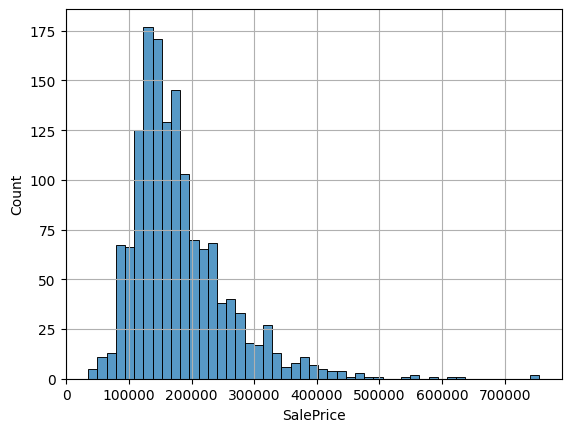

In [47]:
# Построить гистограмму SalePrice + распределение (Seaborn distplot).
sns.histplot(data=df, x='SalePrice')
plt.grid()
plt.show()


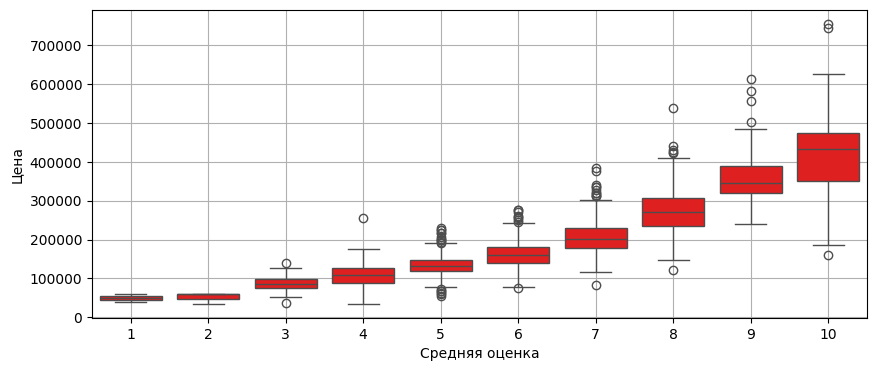

In [48]:
# Построить boxplot: OverallQual vs SalePrice.

plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x='OverallQual', y='SalePrice', color='red')
plt.xlabel('Средняя оценка')
plt.ylabel('Цена')
plt.grid()
plt.show()

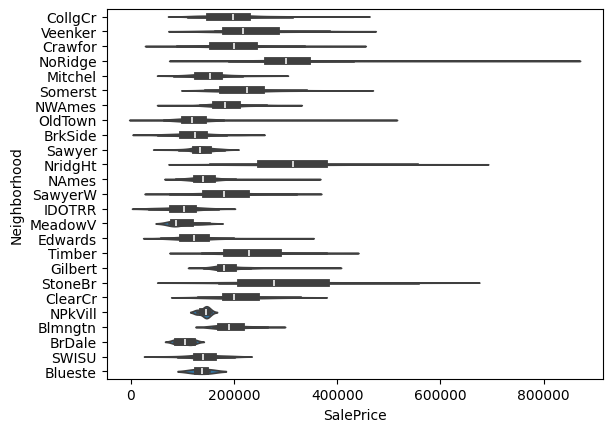

In [49]:
# Построить violinplot: Neighborhood vs SalePrice.

sns.violinplot(data=df, x='SalePrice', y='Neighborhood')
plt.show()

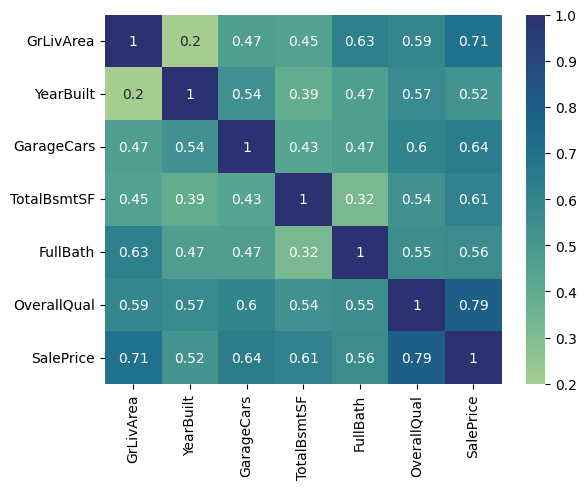

In [50]:
# Построить heatmap корреляции между 6 числовыми признаками.
sns.heatmap(data=df.corr(numeric_only=True), annot=True, cmap='crest')
plt.show()

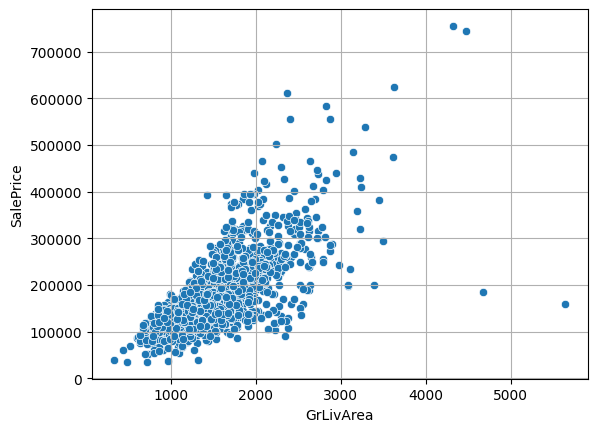

In [51]:
# Построить scatterplot:
# GrLivArea vs SalePrice
# TotalBsmtSF vs SalePrice
# YearBuilt vs SalePrice

sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.grid()
plt.show()

In [52]:
df['GrLivArea'].sort_values(ascending=False)

,GrLivArea
1298,5642
523,4676
1182,4476
691,4316
1169,3627
...,...
528,605
29,520
916,480
1100,438


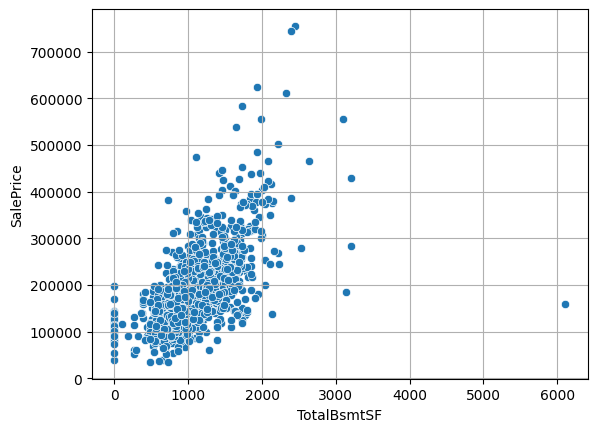

In [53]:
sns.scatterplot(data=df, x='TotalBsmtSF', y='SalePrice')
plt.grid()
plt.show()

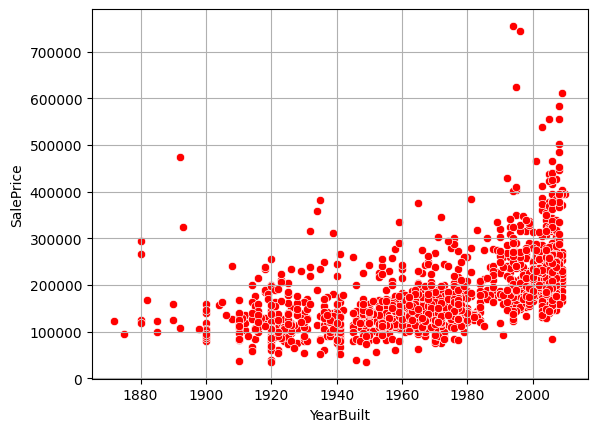

In [54]:
sns.scatterplot(data=df, x='YearBuilt', y='SalePrice', color='red')
plt.grid()
plt.show()

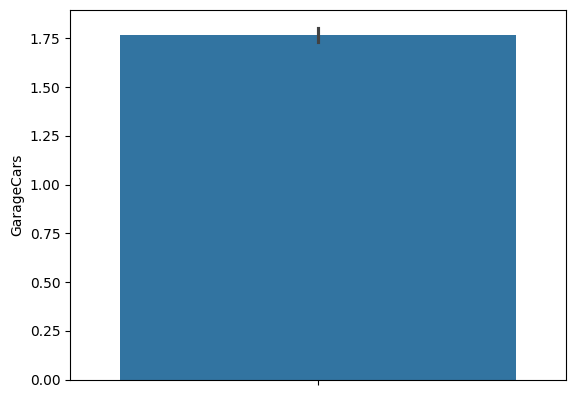

In [55]:
# Построить barplot: средняя цена по GarageCars.

sns.barplot(data=df, y='GarageCars')
plt.show()

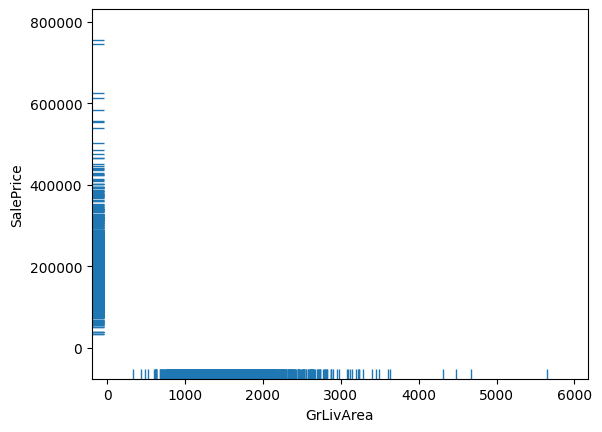

In [56]:
# Построить линейную регрессию regplot для GrLivArea vs SalePrice.
sns.rugplot(data=df, x='GrLivArea', y='SalePrice')
plt.show()

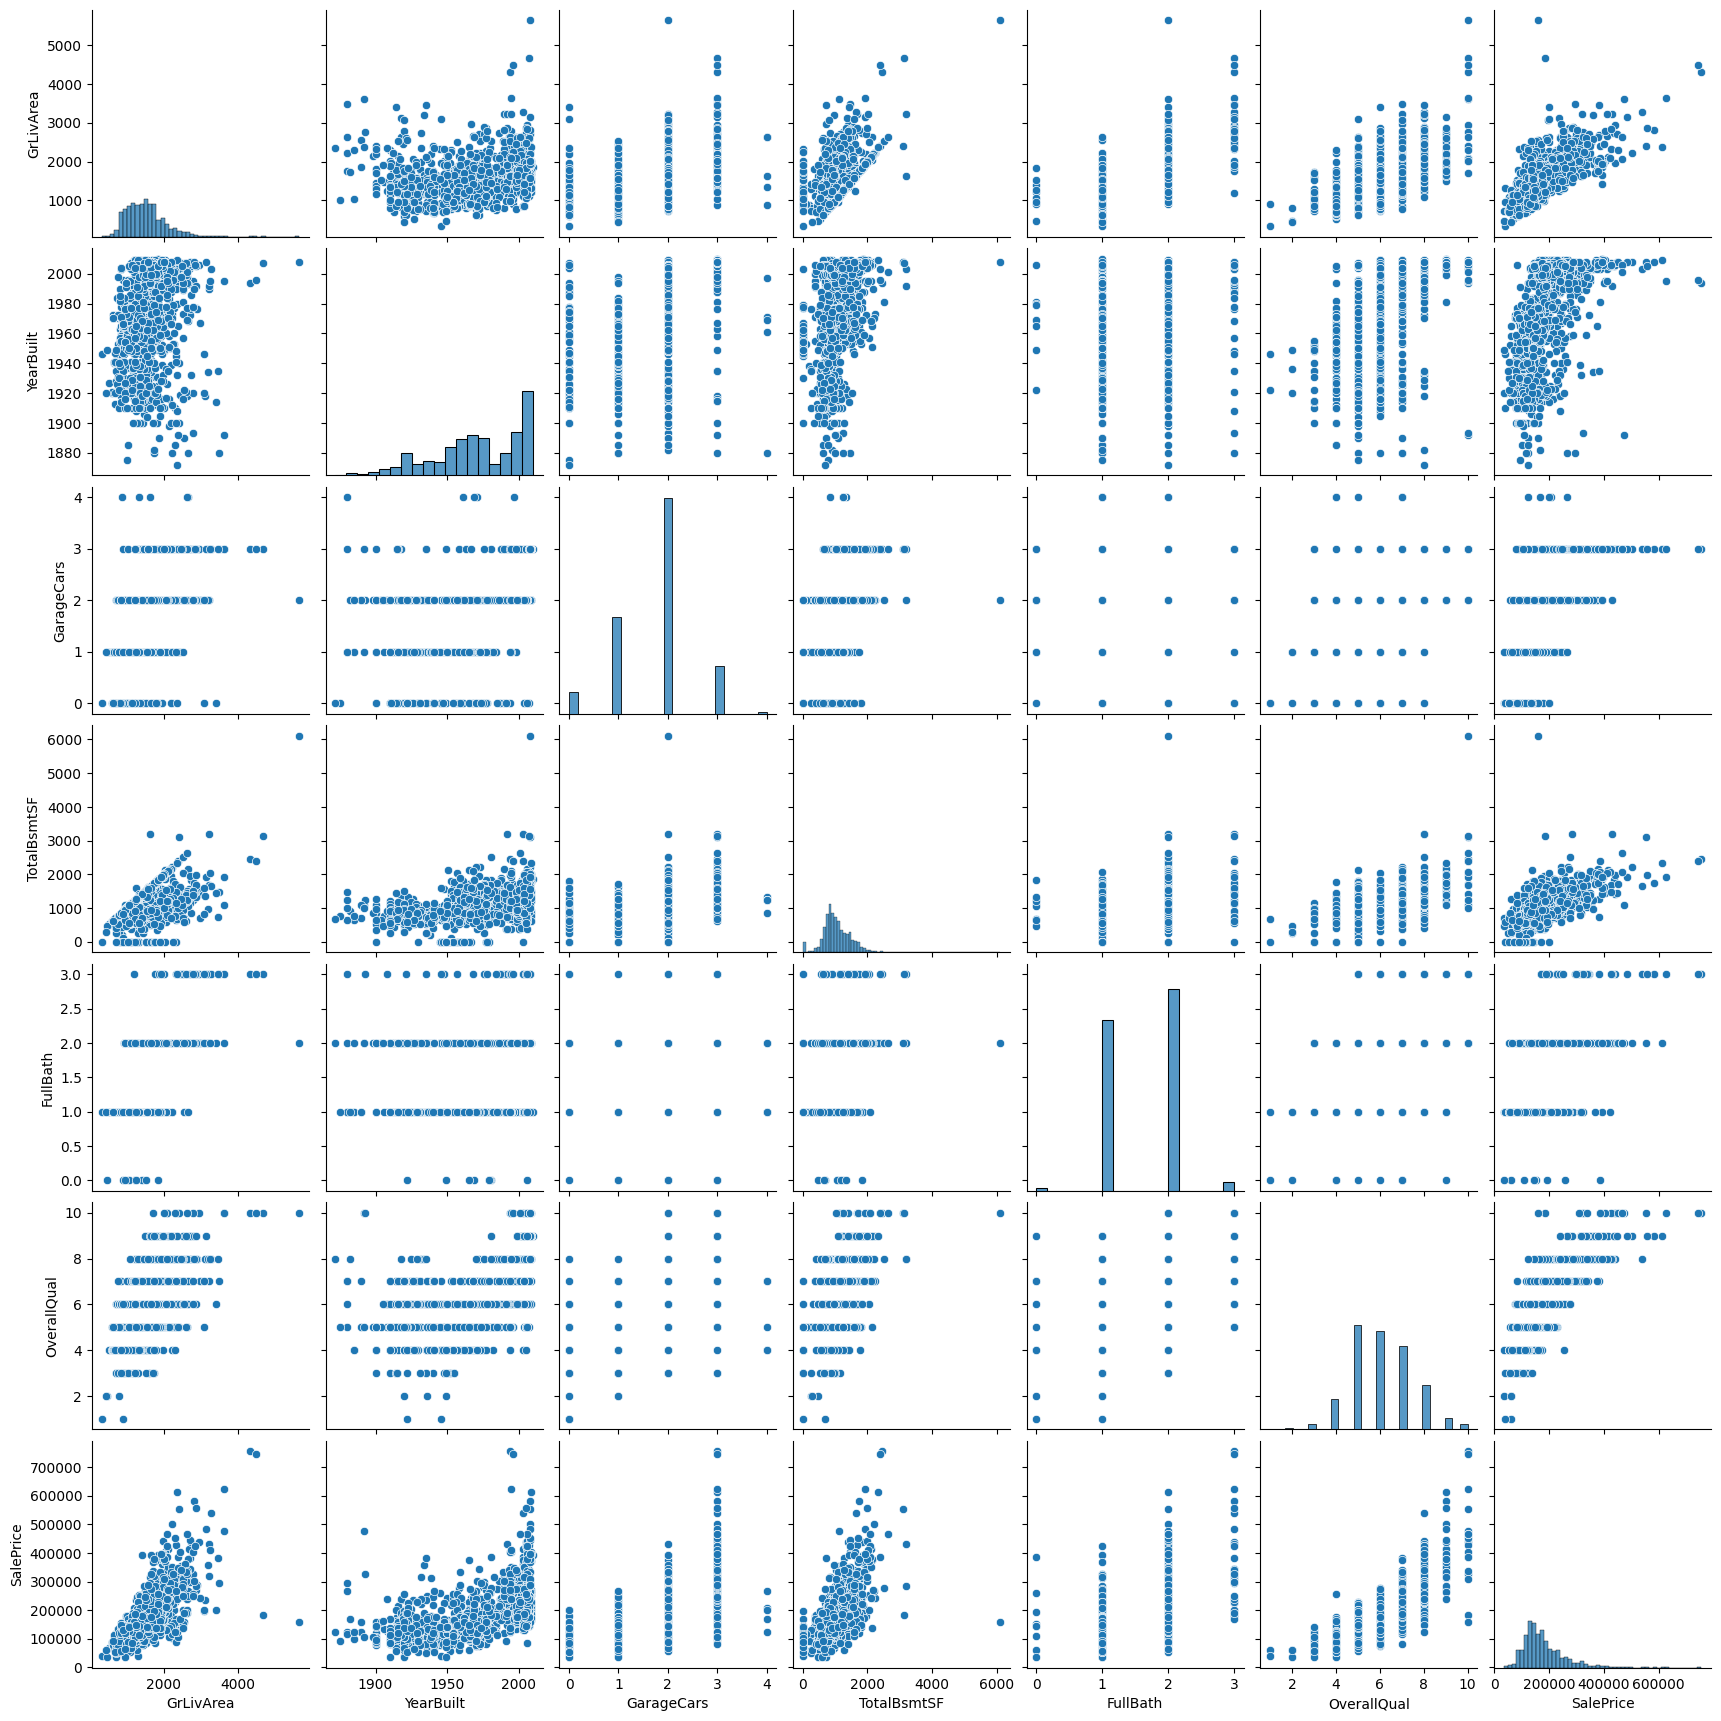

In [57]:
# Построить pairplot по всем числовым признакам.
sns.pairplot(df)
plt.show()


In [58]:
df.dtypes

,0
GrLivArea,int64
YearBuilt,int64
GarageCars,int64
TotalBsmtSF,int64
FullBath,int64
OverallQual,int64
Neighborhood,object
SalePrice,int64


In [59]:
# Обработать пропущенные значения (если есть)
df.isnull().sum()

,0
GrLivArea,0
YearBuilt,0
GarageCars,0
TotalBsmtSF,0
FullBath,0
OverallQual,0
Neighborhood,0
SalePrice,0


In [60]:
# Преобразовать Neighborhood в числовой (one-hot или LabelEncoder).

df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True).astype(int)

In [61]:
df

,GrLivArea,YearBuilt,GarageCars,TotalBsmtSF,FullBath,OverallQual,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1710,2003,2,856,2,7,208500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1262,1976,2,1262,2,6,181500,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1786,2001,2,920,2,7,223500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1717,1915,3,756,1,7,140000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2198,2000,3,1145,2,8,250000,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1647,1999,2,953,2,6,175000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1456,2073,1978,2,1542,2,6,210000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1457,2340,1941,1,1152,2,7,266500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1458,1078,1950,1,1078,1,5,142125,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [62]:
# Нормализовать числовые признаки (MinMaxScaler или StandardScaler)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.drop(columns='SalePrice'))

In [63]:
scaled_data

array([[ 0.37033344,  1.05099379,  0.31172464, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.48251191,  0.15673371,  0.31172464, ..., -0.13199092,
        -0.16347148, 11.47725023],
       [ 0.51501256,  0.9847523 ,  0.31172464, ..., -0.13199092,
        -0.16347148, -0.08712888],
       ...,
       [ 1.56964722, -1.00249232, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.83278768, -0.70440562, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888],
       [-0.49393395, -0.20759447, -1.02685765, ..., -0.13199092,
        -0.16347148, -0.08712888]])

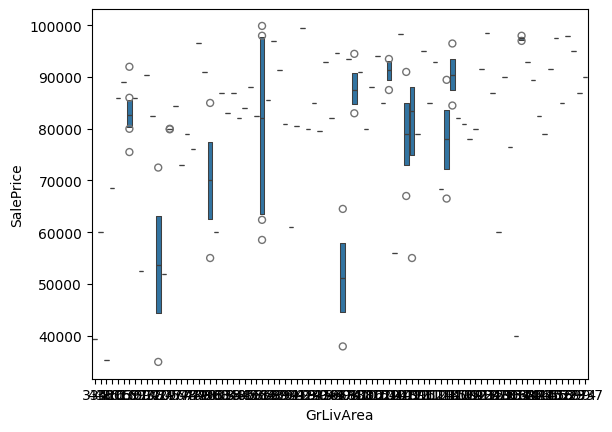

In [64]:
# Проверить выбросы (boxplot) и удалить из GrLivArea и SalePrice.

sns.boxenplot(data=df[df['SalePrice']  < 100000 ], x='GrLivArea', y='SalePrice' )
plt.show()

In [65]:
# Разделить данные на X и y, где y = SalePrice.
x = scaled_data
y = df['SalePrice']

In [66]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [67]:
from sklearn.linear_model import LinearRegression
lin_model = LinearRegression()

In [68]:
lin_model.fit(x_train, y_train)

LinearRegression()

In [69]:
y_pred = lin_model.predict(x_test)

In [70]:
from sklearn.metrics import r2_score
r2_score(y_pred, y_test)

0.7511188845217367

In [71]:
import joblib
joblib.dump(lin_model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl ')

['scaler.pkl ']

In [73]:
li = []
for i in df:
  subword = 'Neighborhood'
  if subword in i:
    li.append(i[len(subword)])

print(li)

['_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_', '_']
